**Домашнее задание 4**

Во второй части третьего дз предлагается поработать с несколькими различными датасетами из соревнований на Kaggle, все данные я выкачал в [папку](https://drive.google.com/drive/folders/1M6NmnFOvCj4Y7Hgc5sFnHK4E6mRkf-lH?usp=sharing). Необходимо создать визуализации в соответствии с заданием, необходимая библиотека для использования будет указана в каждом пункте. Один датасет – одна библиотека для визуализации. Не забывайте подписывать график и оси!

У каждого заданий указано число баллов, которое за него можно получить.
В каждой задаче постарайтесь придумать несколько решений. Решением должен быть Jupyter notebook / ссылка на Colab

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline

netflix_data = pd.read_csv('netflix_titles.csv')
heart_data = pd.read_csv('heart_failure_clinical_records_dataset.csv')
fifa_data = pd.read_csv('CompleteDataset.csv', low_memory=False)

1. Посмотрите на данные из соревнования [Netflix Movies and TV Shows](https://www.kaggle.com/shivamb/netflix-shows). С использованием библиотеки matplotlib создайте следующие визуализации:

    а. Постройте [круговую диаграмму](https://en.wikipedia.org/wiki/Pie_chart), на которой отобразите распределение долей числа фильмов+сериалов последних четырех лет (2018-2021). Укажите на круговой диаграмме проценты, которые составляет контент каждого года с 2018 по 2021 вкл. от общего числа контента за 2018-2021 гг. Цель – посмотреть на соотношение общего числа снятых фильмов и сериалов за последние 4 года. Было бы неплохо, если год, в которых вышло больше всего контента на платформе, был некоторым образом выделен. (1б).
    
    б. Постройте точно такой же по содержанию [donut chart](https://datavizcatalogue.com/methods/donut_chart.html) (0.4б)

    в. Постройте горизонтальный bar plot, в котором сравните число фильмов и сериалов (два горизонтальных стоблца для каждого года) по всем годам. Цель – посмотреть изменение отношения числа фильмов к числу сериалов по годам. Можете использовать для демонстрации этого другой тип графика (0.7б)

    г. Постройте две любые другие визуализации с данными этого датасета (по 0.6б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл (например, считать зависимость длины фильма от числа букв в имени режиссера – бессмысленно). Хотя бы в одной из визуализаций сделайте несколько миниграфиков (subplots) в одном.

In [16]:
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


а. Постройте круговую диаграмму, на которой отобразите распределение долей числа фильмов+сериалов последних четырех лет (2018-2021). Укажите на круговой диаграмме проценты, которые составляет контент каждого года с 2018 по 2021 вкл. от общего числа контента за 2018-2021 гг. Цель – посмотреть на соотношение общего числа снятых фильмов и сериалов за последние 4 года. Было бы неплохо, если год, в которых вышло больше всего контента на платформе, был некоторым образом выделен. (1б).

In [17]:
netflix_data['release_year'] = pd.to_numeric(netflix_data['release_year'], errors='coerce')

netflix_filtered = netflix_data[
    (netflix_data['release_year'] >= 2018) & 
    (netflix_data['release_year'] <= 2021)
]

content_by_year = netflix_filtered['release_year'].value_counts().sort_index()
max_year = content_by_year.idxmax()

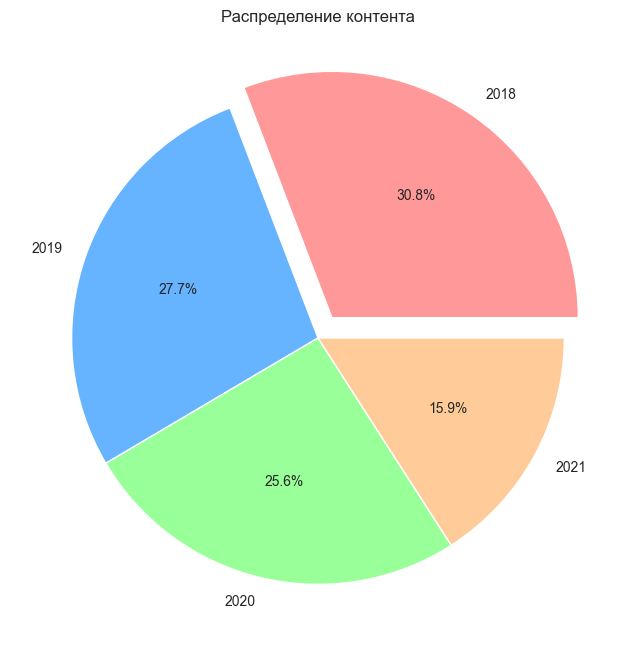

In [49]:
content_by_year.plot(kind='pie', autopct='%1.1f%%', 
                      colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
                      explode=[0.1 if y == max_year else 0 for y in content_by_year.index],
                      labels=[int(y) for y in content_by_year.index],
                      figsize=(10, 8), ylabel='')
plt.title('Распределение контента')
plt.show()

б. Постройте точно такой же по содержанию donut chart (0.4б)

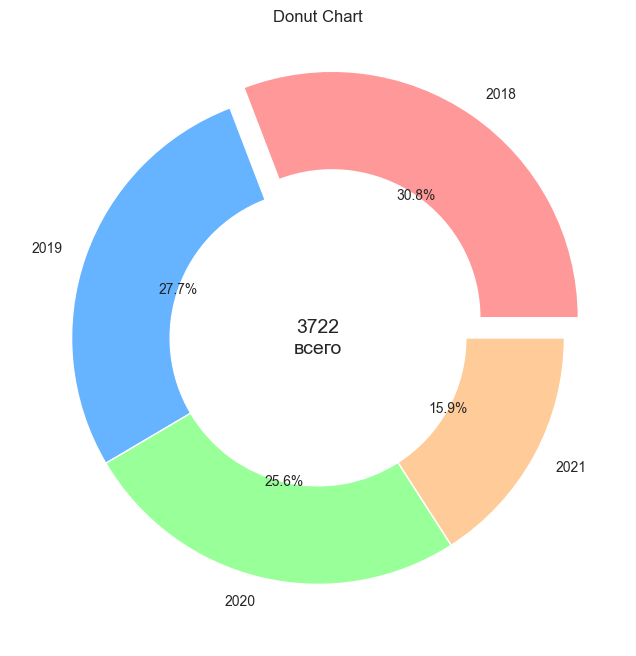

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.pie(content_by_year.values,
       labels=[int(year) for year in content_by_year.index],
       autopct='%1.1f%%',
       colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'],
       explode=[0.1 if year == max_year else 0 for year in content_by_year.index],
       wedgeprops={'width': 0.4})
plt.text(0, 0, f'{content_by_year.sum()}\nвсего', ha='center', va='center', fontsize=14)
plt.title('Donut Chart')
plt.show()

в. Постройте горизонтальный bar plot, в котором сравните число фильмов и сериалов (два горизонтальных стоблца для каждого года) по всем годам. Цель – посмотреть изменение отношения числа фильмов к числу сериалов по годам. Можете использовать для демонстрации этого другой тип графика (0.7б)

In [6]:
content_type_by_year = netflix_filtered.groupby(['release_year', 'type']).size().unstack(fill_value=0)

In [7]:
content_type_by_year

type,Movie,TV Show
release_year,,
2018,767,380
2019,633,397
2020,517,436
2021,277,315


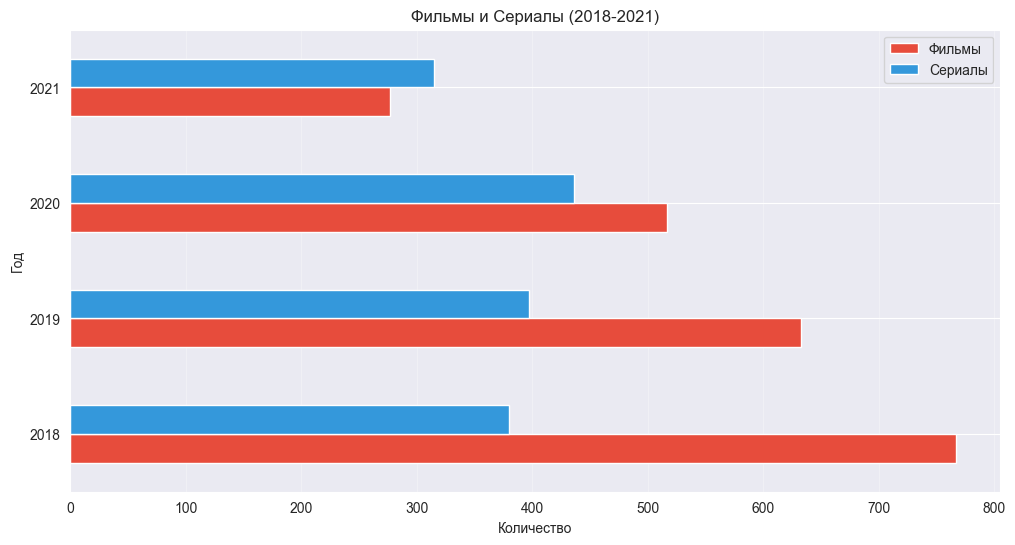

In [23]:
content_type_by_year.plot(kind='barh', figsize=(12, 6), color=['#e74c3c', '#3498db'])
plt.xlabel('Количество')
plt.ylabel('Год')
plt.title('Фильмы и Сериалы (2018-2021)')
plt.legend(['Фильмы', 'Сериалы'])
plt.grid(axis='x', alpha=0.3)
plt.show()

In [24]:
for year in content_type_by_year.index:
    movies = content_type_by_year.loc[year, 'Movie']
    shows = content_type_by_year.loc[year, 'TV Show']
    ratio = movies / shows
    print(f'{int(year)}: {ratio:.2f}')

2018: 2.02
2019: 1.59
2020: 1.19
2021: 0.88


г. Постройте две любые другие визуализации с данными этого датасета (по 0.6б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл (например, считать зависимость длины фильма от числа букв в имени режиссера – бессмысленно). Хотя бы в одной из визуализаций сделайте несколько миниграфиков (subplots) в одном.

In [25]:
countries = []
for c in netflix_data['country'].dropna():
    countries.extend([x.strip() for x in str(c).split(',')])

from collections import Counter
top_countries = pd.Series(Counter(countries)).nlargest(10)

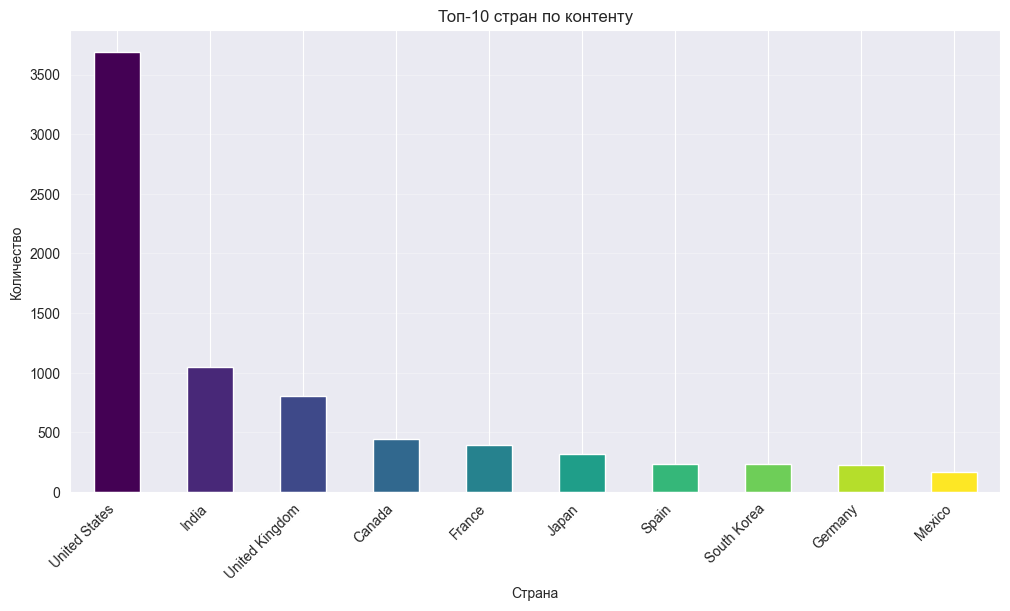

In [26]:
top_countries.plot(kind='bar', figsize=(12, 6), color=plt.cm.viridis(np.linspace(0, 1, 10)))
plt.xlabel('Страна')
plt.ylabel('Количество')
plt.title('Топ-10 стран по контенту')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [27]:
yearly = netflix_data[netflix_data['release_year'] >= 2010].groupby('release_year').size()

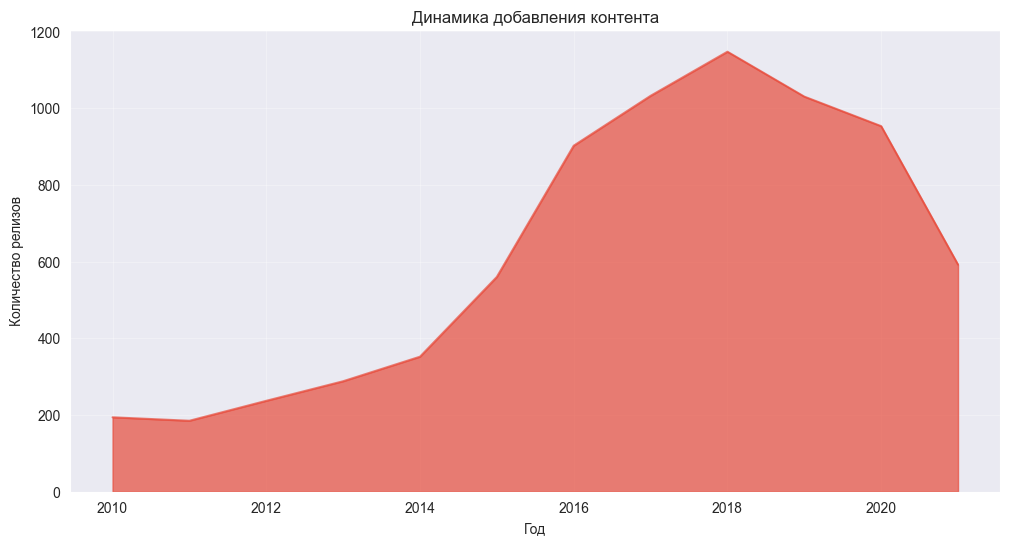

In [28]:
yearly.plot(kind='area', figsize=(12, 6), color='#e74c3c', alpha=0.7)
plt.xlabel('Год')
plt.ylabel('Количество релизов')
plt.title('Динамика добавления контента')
plt.grid(True, alpha=0.3)
plt.show()


2. Посмотрите на данные соревнования [Heart Failure Prediction](https://www.kaggle.com/andrewmvd/heart-failure-clinical-data). С использованием библиотеки seaborn (основная функция графика должна отрисовываться функцией из seaborn) создайте следующие визуализации:

    а. Нарисуйте на одном графике две линии – число смертей (DEATH_EVENT=1) и не смертей(DEATH_EVENT!=1) в зависимости от возраста. (0.5б)

    б. Постройте тепловую карту, в которой для каждой пары значений (Процент крови, покидающей сердце при каждом сокращении; Возраст) будет выведено число смертей (соответственно, людей такого возраста и с таким показателем ejection_fraction). Цвет ячейки в тепловой карте будет зависеть от значения этого же показателя. (1.7б). Пример визуализации в конце ноутбука.

    в. Добавьте в любой график из задачи 1 стиль оформления из seaborn. (0.1б)

    г. Постройте две любые другие визуализации с данными этого датасета (по 0.5б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл. Пользуемся всё ещё seaborn обязательно, если необходимо, в пункте "г" можно использовать что-то дополнительно из matplotlib.

In [29]:
heart_data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


а. Нарисуйте на одном графике две линии – число смертей (DEATH_EVENT=1) и не смертей(DEATH_EVENT!=1) в зависимости от возраста. (0.5б)

In [30]:
deaths_by_age = heart_data[heart_data['DEATH_EVENT'] == 1].groupby('age').size()
survived_by_age = heart_data[heart_data['DEATH_EVENT'] == 0].groupby('age').size()

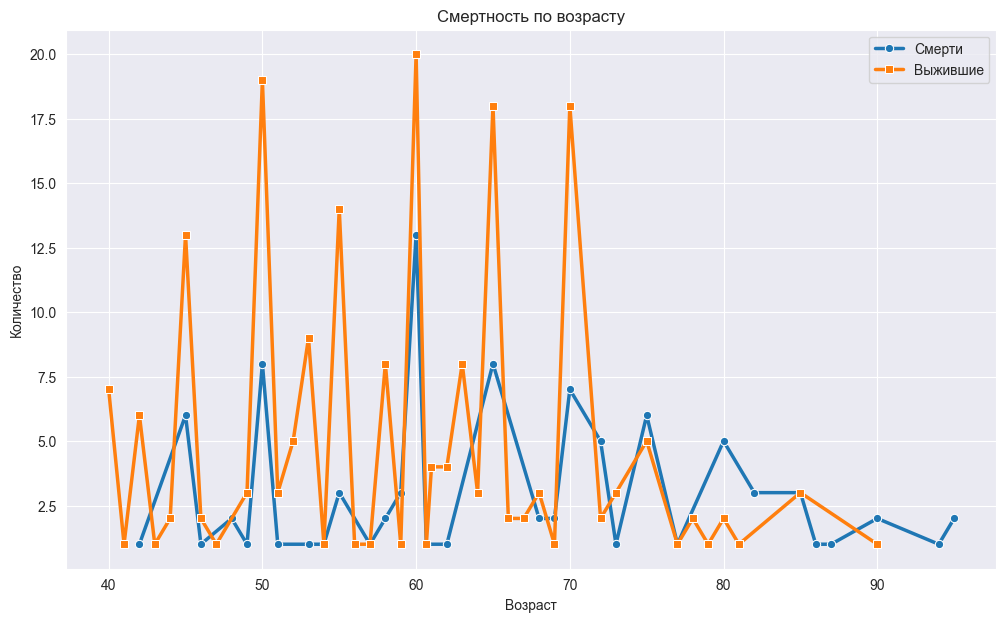

In [31]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(x=deaths_by_age.index, y=deaths_by_age.values, marker='o', label='Смерти', ax=ax, linewidth=2.5)
sns.lineplot(x=survived_by_age.index, y=survived_by_age.values, marker='s', label='Выжившие', ax=ax, linewidth=2.5)
ax.set_xlabel('Возраст')
ax.set_ylabel('Количество')
ax.set_title('Смертность по возрасту')
plt.show()

б. Постройте тепловую карту, в которой для каждой пары значений (Процент крови, покидающей сердце при каждом сокращении; Возраст) будет выведено число смертей (соответственно, людей такого возраста и с таким показателем ejection_fraction). Цвет ячейки в тепловой карте будет зависеть от значения этого же показателя. (1.7б). Пример визуализации в конце ноутбука.

In [32]:
heatmap_data = heart_data[heart_data['DEATH_EVENT'] == 1].groupby(['age', 'ejection_fraction']).size().unstack(fill_value=0)

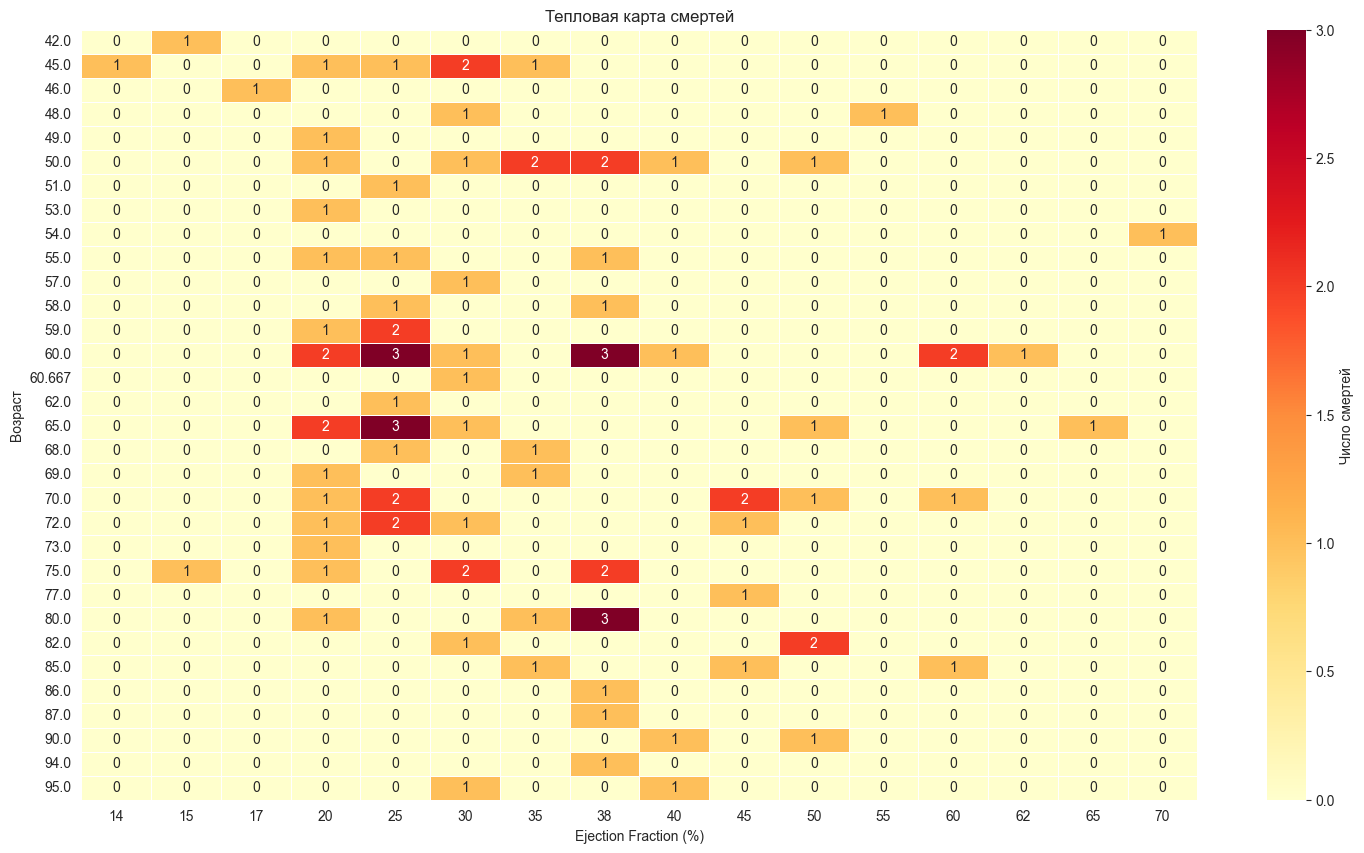

In [33]:
plt.figure(figsize=(18, 10))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Число смертей'})
plt.xlabel('Ejection Fraction (%)')
plt.ylabel('Возраст')
plt.title('Тепловая карта смертей')
plt.show()

в. Добавьте в любой график из задачи 1 стиль оформления из seaborn. (0.1б)

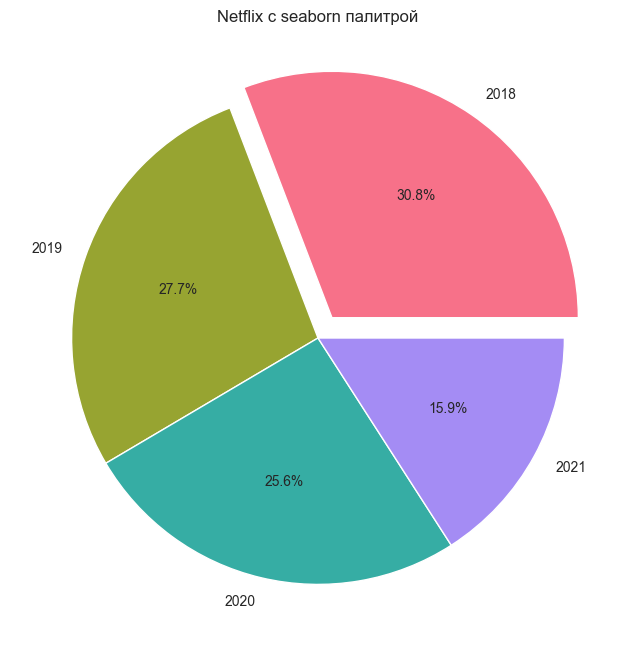

In [34]:
sns.set_style('darkgrid')
content_by_year.plot(kind='pie', autopct='%1.1f%%', 
                      colors=sns.color_palette('husl', len(content_by_year)),
                      explode=[0.1 if y == max_year else 0 for y in content_by_year.index],
                      labels=[int(y) for y in content_by_year.index],
                      figsize=(10, 8), ylabel='')
plt.title('Netflix с seaborn палитрой')
plt.show()
sns.set_style('whitegrid')

г. Постройте две любые другие визуализации с данными этого датасета (по 0.5б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл. Пользуемся всё ещё seaborn обязательно, если необходимо, в пункте "г" можно использовать что-то дополнительно из matplotlib.

C:\Users\User\AppData\Local\Temp\ipykernel_7560\4214485647.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=heart_data, x='DEATH_EVENT', y='age', palette='Set2')


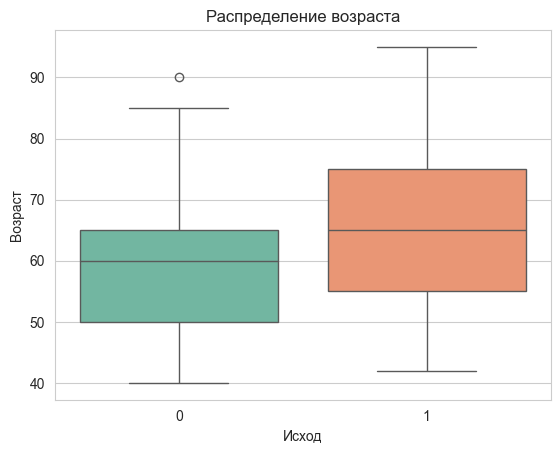

In [35]:
sns.boxplot(data=heart_data, x='DEATH_EVENT', y='age', palette='Set2')
plt.xlabel('Исход')
plt.ylabel('Возраст')
plt.title('Распределение возраста')
plt.show()

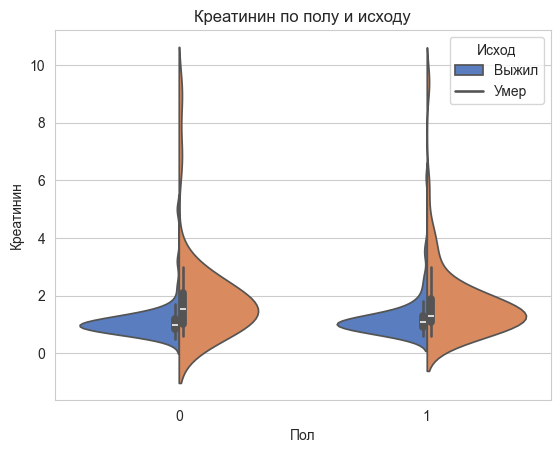

In [36]:
sns.violinplot(data=heart_data, x='sex', y='serum_creatinine', hue='DEATH_EVENT', split=True, palette='muted')
plt.xlabel('Пол')
plt.ylabel('Креатинин')
plt.title('Креатинин по полу и исходу')
plt.legend(title='Исход', labels=['Выжил', 'Умер'])
plt.show()

3. Посмотрите на данные соревнования [FIFA 18 Complete Player Dataset](https://www.kaggle.com/thec03u5/fifa-18-demo-player-dataset). С использованием библиотеки plotly создайте следующие интерактивные визуализации. В пп. а-г используются данные только из файла CompleteDataset.csv:

    а. Посчитаем среднюю зарплату для топ-футболистов из отдельных стран (первые 1000 по зарплате среди всех игроков). Чтобы исключить случаи, при которых футболистов из страны мало и они высокооплачиваемые, наложим ограничение, чтобы в топ-1000 из страны было хотя бы 11 человек (набралась команда).Постройте зависимость средней зарплата топ-футболистов в зависимости от страны, которую они представляют (в виду bar plot). При наведении на соответствующую колонку должно отображаться точное значение средней зарплаты. Не забудьте, что где-то на графике надо указать единицы измерения! (0.8б)

    б. Проанализируйте график из п. а. Где равномернее распределены зарплаты, а где есть суперзвезда и все остальные? Какая ситуация у сборной России по футболу? (0.3б)

    в. Как зарплата согласуется с навыками дриблинга? Исключите из выборки вратаей по понятным причинам, посмотрите на топ-100 самых высокооплачиваемых полевых игроков. Постройте зависимость зарплаты от навыков дриблинга (scatter plot). При наведении мышки на каждую точку должно показываться ИМЯ футболиста, его возраст и зарплата. (0.8б)

    г. Проанализируйте выбросы в этой таблице (точки, отстоящие больше всего от основной массы, или же явно не подчиняющиеся какому-то тренду). Как вы думаете, с чем это связано (если вы не интересуетесь футболом, погуглите этих футболистов и попробуйте найти логичное происходящему, согласующееся с интуицией). (0.5б)

    д. Постройте две любые другие визуализации с данными этого датасета (по 0.5б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл. Пользоваться для визуализации, как и везде в п.3, можно только plotly

In [37]:
fifa_data.head()

,Unnamed: 0,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,RB,RCB,RCM,RDM,RF,RM,RS,RW,RWB,ST
0,0,Cristiano Ronaldo,32,https://cdn.sofifa.org/48/18/players/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Real Madrid CF,https://cdn.sofifa.org/24/18/teams/243.png,...,61.0,53.0,82.0,62.0,91.0,89.0,92.0,91.0,66.0,92.0
1,1,L. Messi,30,https://cdn.sofifa.org/48/18/players/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,93,93,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,57.0,45.0,84.0,59.0,92.0,90.0,88.0,91.0,62.0,88.0
2,2,Neymar,25,https://cdn.sofifa.org/48/18/players/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,94,Paris Saint-Germain,https://cdn.sofifa.org/24/18/teams/73.png,...,59.0,46.0,79.0,59.0,88.0,87.0,84.0,89.0,64.0,84.0
3,3,L. Suárez,30,https://cdn.sofifa.org/48/18/players/176580.png,Uruguay,https://cdn.sofifa.org/flags/60.png,92,92,FC Barcelona,https://cdn.sofifa.org/24/18/teams/241.png,...,64.0,58.0,80.0,65.0,88.0,85.0,88.0,87.0,68.0,88.0
4,4,M. Neuer,31,https://cdn.sofifa.org/48/18/players/167495.png,Germany,https://cdn.sofifa.org/flags/21.png,92,92,FC Bayern Munich,https://cdn.sofifa.org/24/18/teams/21.png,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


а. Посчитаем среднюю зарплату для топ-футболистов из отдельных стран (первые 1000 по зарплате среди всех игроков). Чтобы исключить случаи, при которых футболистов из страны мало и они высокооплачиваемые, наложим ограничение, чтобы в топ-1000 из страны было хотя бы 11 человек (набралась команда).Постройте зависимость средней зарплата топ-футболистов в зависимости от страны, которую они представляют (в виду bar plot). При наведении на соответствующую колонку должно отображаться точное значение средней зарплаты. Не забудьте, что где-то на графике надо указать единицы измерения! (0.8б)

In [38]:
fifa_data['Wage_Clean'] = fifa_data['Wage'].str.replace('€', '').str.replace('K', '')
fifa_data['Wage_Clean'] = pd.to_numeric(fifa_data['Wage_Clean'], errors='coerce') * 1000

In [39]:
top_1000 = fifa_data.nlargest(1000, 'Wage_Clean')
country_stats = top_1000.groupby('Nationality').agg({'Wage_Clean': 'mean', 'Name': 'count'}).rename(columns={'Name': 'Count'})
country_stats = country_stats[country_stats['Count'] >= 11].sort_values('Wage_Clean', ascending=False)

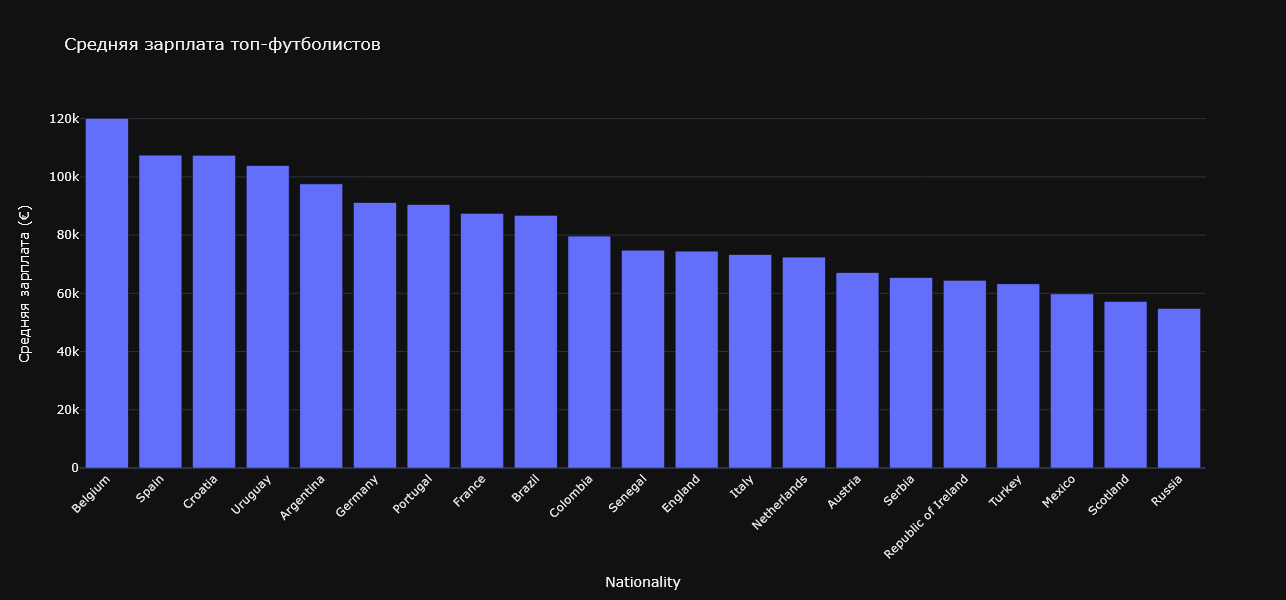

In [40]:
fig = px.bar(country_stats, x=country_stats.index, y='Wage_Clean',
             labels={'x': 'Страна', 'Wage_Clean': 'Средняя зарплата (€)'},
             title='Средняя зарплата топ-футболистов')
fig.update_layout(xaxis_tickangle=-45, height=600)
fig.show()

б. Проанализируйте график из п. а. Где равномернее распределены зарплаты, а где есть суперзвезда и все остальные? Какая ситуация у сборной России по футболу? (0.3б)

In [41]:
for country in country_stats.index[:5]:
    wages = top_1000[top_1000['Nationality'] == country]['Wage_Clean']
    print(f'{country}: mean={wages.mean():.0f}, median={wages.median():.0f}, std={wages.std():.0f}')

Belgium: mean=120074, median=115000, std=65733
Spain: mean=107467, median=81500, std=64959
Croatia: mean=107412, median=84000, std=82141
Uruguay: mean=103833, median=55000, std=133110
Argentina: mean=97562, median=66500, std=89063


в. Как зарплата согласуется с навыками дриблинга? Исключите из выборки вратаей по понятным причинам, посмотрите на топ-100 самых высокооплачиваемых полевых игроков. Постройте зависимость зарплаты от навыков дриблинга (scatter plot). При наведении мышки на каждую точку должно показываться ИМЯ футболиста, его возраст и зарплата. (0.8б)

In [43]:
if 'Position' in fifa_data.columns:
    field_players = fifa_data[fifa_data['Position'] != 'GK']
elif 'Preferred Positions' in fifa_data.columns:
    field_players = fifa_data[~fifa_data['Preferred Positions'].str.contains('GK', na=False)]
else:
    field_players = fifa_data.copy()

top_100_field = field_players.nlargest(100, 'Wage_Clean')

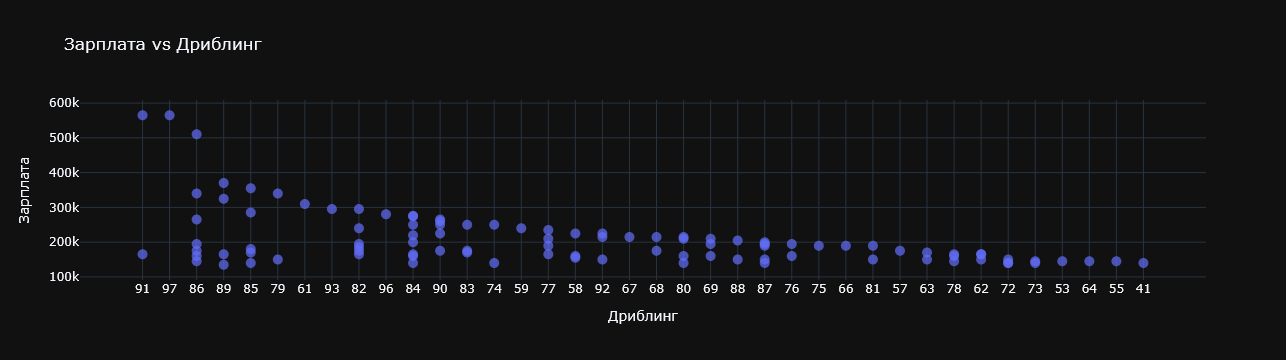

In [44]:
fig = px.scatter(top_100_field, x='Dribbling', y='Wage_Clean',
                 hover_data=['Name', 'Age', 'Wage_Clean'],
                 labels={'Dribbling': 'Дриблинг', 'Wage_Clean': 'Зарплата'},
                 title='Зарплата vs Дриблинг')
fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

д. Постройте две любые другие визуализации с данными этого датасета (по 0.5б за каждую). Необходимо, чтобы придуманные вами визуализации по возможности отличались друг от друга и от выше приведенных, а так же имели какой-то понятный смысл. Пользоваться для визуализации, как и везде в п.3, можно только plotly

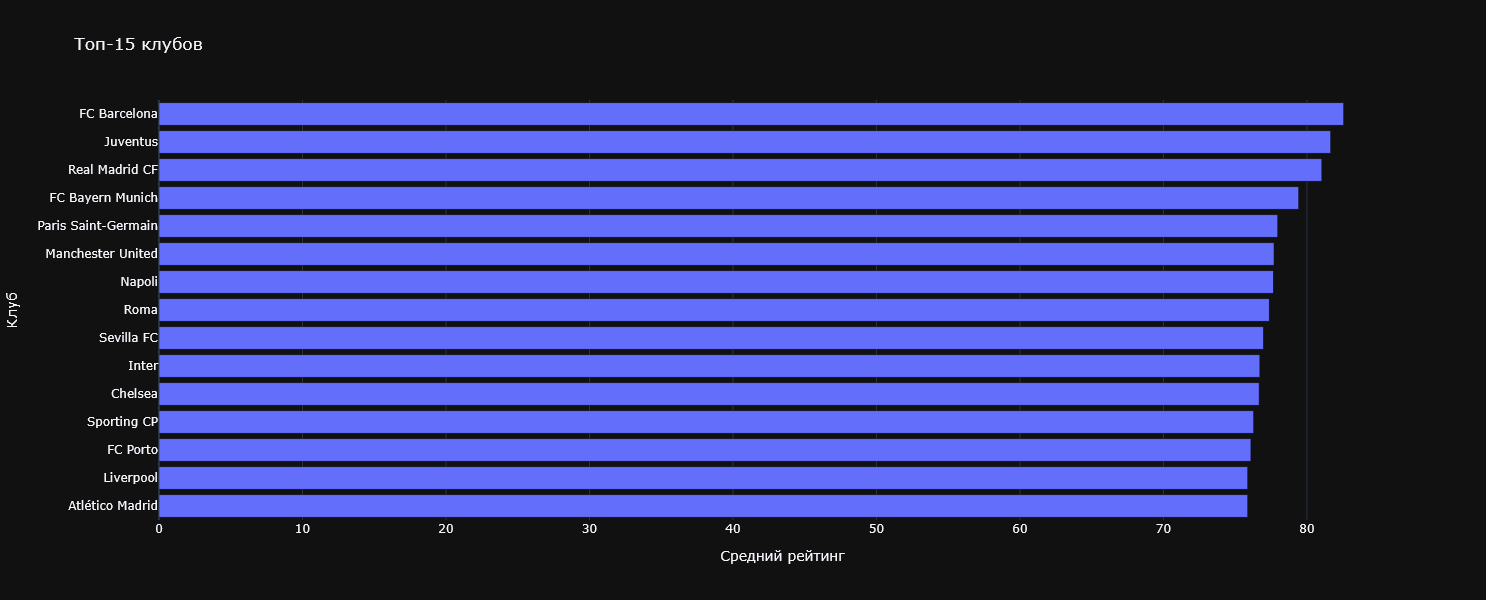

In [48]:
club_avg = fifa_data.groupby('Club')['Overall'].mean().nlargest(15).sort_values(ascending=True)
fig = px.bar(x=club_avg.values, y=club_avg.index, orientation='h',labels={'x': 'Средний рейтинг', 'y': 'Клуб'},title='Топ-15 клубов')
fig.update_layout(height=600)
fig.show()